# VDSR-ResNeXt for Image Super-Resolution

This notebook implements a variant of VDSR by incorporating ResNeXt-style blocks. It follows a similar structure to the [previous VDSR notebook](https://www.kaggle.com/code/assemelqirsh/vdsr-pytorch), including data preparation, model definition, training, and evaluation.

# ResNeXt-Specific Hyperparameters:

### **CARDINALITY:** Number of grouped convolutions (default **32**)  
- Increase/decrease to change model complexity  
- Higher values can capture more complex features  

### **WIDTH_PER_GROUP:** Width of each group (default **4**)  
- Adjust to control feature representation  

### **BASE_WIDTH:** Base width of the network (default **64**)  
- Influences the overall network capacity  

---

# Model Architecture Tuning:

### **NUM_LAYERS:** Total number of layers (default **20**)  
- More layers can capture more complex features  
- Too many layers might lead to overfitting  
- Experiment with different layer configurations  

---

# Training Hyperparameters to Adjust:

### **LEARNING_RATE:** Current value is **0.001**  
- Try values like **0.0001, 0.01**  

### **WEIGHT_DECAY:** Current is **1e-4**  
- Adjust to control regularization (e.g., **1e-3, 1e-5**)  

### **BATCH_SIZE:** Current is **32**  
- Larger batches can stabilize training  
- Try **16, 64, 128**  

### **EPOCHS:** Current is **50**  
- Increase if performance is still improving  
- Add early stopping mechanism if needed  

---

# Performance Improvement Strategies:

- Add data augmentation in `prepare_data()`
- Experiment with different optimizers (**SGD with momentum, RMSprop**)
- Try different loss functions (**L1Loss, Huber Loss**)
- Implement learning rate scheduling strategies  

---

# Key Differences from Previous VDSR:

- Introduced **ResNeXt block** with grouped convolutions  
- Added **batch normalization**  
- More complex residual learning approach  

---

# Potential Variations to Try:

- Adjust **CARDINALITY** and **WIDTH_PER_GROUP**  
- Change **number of layers**  
- Modify **base convolution configurations**  
- Experiment with **different regularization techniques**  

---

# When You Run This, Monitor:

- **Training and validation losses**  
- **PSNR and SSIM metrics**  
- **Visual quality** of super-resolved images  


# Implementation

## 0. DEBUGGING AND CONFIGURATION SECTION

In [1]:
# This section allows for easy configuration and debugging
DEBUG_MODE = True  # Set to True for verbose output
VERBOSE_LEVEL = 1  # 0: Minimal, 1: Normal, 2: Detailed

# Comprehensive Logging Function
def debug_log(message, level=1):
    """
    Centralized logging function for easier debugging
    """
    if DEBUG_MODE and level <= VERBOSE_LEVEL:
        print(f"[DEBUG] {message}")

## 1. IMPORTS AND REPRODUCIBILITY

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split
import glob
import cv2
from tqdm import tqdm
import pandas as pd

# Reproducibility Setup
def set_seed(seed=42):
    """
    Set random seeds for reproducibility across libraries
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    debug_log(f"Random seed set to {seed}")

set_seed()

[DEBUG] Random seed set to 42


## 2. CONFIGURATION PARAMETERS

In [3]:
class Config:
    """
    Centralized configuration class for easy parameter management
    """
    # Data Parameters
    IMAGE_SIZE = 128  # Reduced from 224 to save memory
    DATASET_PATH = "/kaggle/input/chest-x-ray-dataset/chest_xray"
    DOWNSCALE_FACTOR = 4

    # Training Parameters
    BATCH_SIZE = 16  # Reduced from 32 to save memory
    EPOCHS = 50
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    LR_DECAY_STEP = 10
    LR_DECAY_GAMMA = 0.5

    # Model Architecture Parameters - Memory Optimized
    CARDINALITY = 8  # Reduced from 32 to save memory
    WIDTH_PER_GROUP = 2  # Reduced from 4 to save memory
    BASE_WIDTH = 32  # Reduced from 64 to save memory
    NUM_LAYERS = 10  # Reduced from 20 to save memory
    
    # Hardware
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    @classmethod
    def display(cls):
        """
        Display all configuration parameters
        """
        print("Current Configuration:")
        for key, value in vars(cls).items():
            if not key.startswith('__') and not callable(value):
                print(f"{key}: {value}")

## 3. CUSTOM MODULES

In [4]:
class ResNeXtBlock(nn.Module):
    """
    ResNeXt Block with grouped convolutions
    Allows for complex feature extraction
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResNeXtBlock, self).__init__()
        
        # Group width calculation
        group_width = int(out_channels * (Config.BASE_WIDTH / 64)) * Config.WIDTH_PER_GROUP
        
        # Convolution layers
        self.conv1 = nn.Conv2d(in_channels, group_width, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(group_width)
        
        self.conv2 = nn.Conv2d(
            group_width, 
            group_width, 
            kernel_size=3, 
            stride=stride, 
            padding=1, 
            groups=Config.CARDINALITY, 
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(group_width)
        
        self.conv3 = nn.Conv2d(group_width, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        # Change from inplace to non-inplace ReLU
        self.relu = nn.ReLU(inplace=False)
    
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        out += self.shortcut(identity)
        out = self.relu(out)
        
        return out


class VDSR_ResNeXt(nn.Module):
    """
    VDSR with ResNeXt Blocks
    Combines Very Deep Super-Resolution with ResNeXt architecture
    """
    def __init__(self, num_layers=Config.NUM_LAYERS, num_filters=64):
        super(VDSR_ResNeXt, self).__init__()
        
        layers = [
            nn.Conv2d(in_channels=1, out_channels=num_filters, kernel_size=3, padding=1),
            nn.ReLU(inplace=False)  # Change from inplace to non-inplace
        ]
        
        for _ in range(num_layers - 2):
            layers.append(ResNeXtBlock(
                in_channels=num_filters, 
                out_channels=num_filters
            ))
            layers.append(nn.ReLU(inplace=False))  # Change from inplace to non-inplace
        
        layers.append(nn.Conv2d(in_channels=num_filters, out_channels=1, kernel_size=3, padding=1))
        
        self.residual = nn.Sequential(*layers)
    
    def forward(self, x):
        return x + self.residual(x)

## 4. DATASET AND DATA LOADING

Notes for Users:
- Modify `limit_per_class` to control dataset size
- Adjust `downscale_factor` to experiment with super-resolution
- Set `DEBUG_MODE` and `VERBOSE_LEVEL` for desired logging detail

In [5]:
class CXRDataset(Dataset):
    """
    Custom Dataset for Chest X-Ray Images
    Handles low-resolution and high-resolution image pairs
    """
    def __init__(self, lr_images, hr_images, transform=None):
        """
        Args:
            lr_images (numpy.ndarray): Low-resolution images
            hr_images (numpy.ndarray): High-resolution images
            transform (callable, optional): Optional transform to be applied
        """
        self.lr_images = lr_images
        self.hr_images = hr_images
        self.transform = transform
        
        debug_log(f"Dataset initialized with {len(lr_images)} image pairs", level=1)
    
    def __len__(self):
        """
        Returns the total number of image pairs
        """
        return len(self.lr_images)
    
    def __getitem__(self, idx):
        """
        Retrieves and preprocesses a single image pair
        
        Args:
            idx (int): Index of the image pair
        
        Returns:
            tuple: Processed low-resolution and high-resolution image tensors
        """
        lr_image = self.lr_images[idx]
        hr_image = self.hr_images[idx]
        
        # Convert to PyTorch tensors
        lr_tensor = torch.from_numpy(lr_image).float()
        hr_tensor = torch.from_numpy(hr_image).float()
        
        # Ensure [C, H, W] format for PyTorch
        lr_tensor = lr_tensor.permute(2, 0, 1)
        hr_tensor = hr_tensor.permute(2, 0, 1)
        
        if self.transform:
            lr_tensor = self.transform(lr_tensor)
            hr_tensor = self.transform(hr_tensor)
        
        return lr_tensor, hr_tensor


def prepare_data(dataset_path, limit_per_class=100, downscale_factor=Config.DOWNSCALE_FACTOR):
    """
    Prepare training and validation data for super-resolution
    
    Args:
        dataset_path (str): Path to the chest X-ray dataset
        limit_per_class (int): Maximum number of images per category
        downscale_factor (int): Factor for creating low-resolution images
    
    Returns:
        tuple: Training and validation data loaders
    """
    debug_log("Starting data preparation...", level=1)
    
    hr_images = []
    categories = ['NORMAL', 'PNEUMONIA']
    
    # Collect images from training directory
    for category in categories:
        # Support both .jpeg and .jpg extensions
        image_paths = (
            glob.glob(os.path.join(dataset_path, 'train', category, '*.jpeg')) +
            glob.glob(os.path.join(dataset_path, 'train', category, '*.jpg'))
        )
        
        debug_log(f"Found {len(image_paths)} {category} images", level=1)
        
        for img_path in tqdm(image_paths[:limit_per_class], desc=f"Processing {category} images"):
            try:
                # Load image in grayscale
                img = cv2.imread(img_path, 0)  # 0 for grayscale
                
                if img is not None:
                    # Resize image to target size
                    img = cv2.resize(img, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
                    
                    # Normalize to [0, 1]
                    img = img.astype(np.float32) / 255.0
                    
                    hr_images.append(img)
            except Exception as e:
                debug_log(f"Error processing {img_path}: {e}", level=2)
    
    hr_images = np.array(hr_images)
    debug_log(f"Total HR images: {hr_images.shape}", level=1)
    
    # Create low-resolution images
    lr_images = []
    for img in tqdm(hr_images, desc="Creating low-resolution images"):
        # Downsample
        low_res = cv2.resize(img, (Config.IMAGE_SIZE // downscale_factor, Config.IMAGE_SIZE // downscale_factor))
        # Upsample back to original size
        low_res = cv2.resize(low_res, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
        lr_images.append(low_res)
    
    lr_images = np.array(lr_images)
    
    # Reshape for the model (add channel dimension)
    hr_images = hr_images.reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    lr_images = lr_images.reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    
    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        lr_images, hr_images, test_size=0.2, random_state=42
    )
    
    # Create PyTorch datasets
    train_dataset = CXRDataset(X_train, y_train)
    val_dataset = CXRDataset(X_val, y_val)
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=True, 
        num_workers=4
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=False, 
        num_workers=4
    )
    
    debug_log(f"Train loader: {len(train_loader)} batches", level=1)
    debug_log(f"Validation loader: {len(val_loader)} batches", level=1)
    
    return train_loader, val_loader


def load_test_data(dataset_path, limit_per_class=50, downscale_factor=Config.DOWNSCALE_FACTOR):
    """
    Load and prepare test data for evaluation
    
    Args:
        dataset_path (str): Path to the chest X-ray dataset
        limit_per_class (int): Maximum number of test images per category
        downscale_factor (int): Factor for creating low-resolution images
    
    Returns:
        tuple: Test data loader, high-resolution images, low-resolution images
    """
    debug_log("Loading test data...", level=1)
    
    test_hr_images = []
    test_lr_images = []
    categories = ['NORMAL', 'PNEUMONIA']
    
    for category in categories:
        # Support both .jpeg and .jpg extensions
        image_paths = (
            glob.glob(os.path.join(dataset_path, 'test', category, '*.jpeg')) +
            glob.glob(os.path.join(dataset_path, 'test', category, '*.jpg'))
        )
        
        debug_log(f"Found {len(image_paths)} {category} test images", level=1)
        
        for img_path in tqdm(image_paths[:limit_per_class], desc=f"Processing {category} test images"):
            try:
                # Load image in grayscale
                img = cv2.imread(img_path, 0)
                
                if img is not None:
                    # Resize image to target size
                    img = cv2.resize(img, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
                    
                    # Normalize to [0, 1]
                    img = img.astype(np.float32) / 255.0
                    
                    # Create low resolution version
                    low_res = cv2.resize(img, (Config.IMAGE_SIZE // downscale_factor, Config.IMAGE_SIZE // downscale_factor))
                    low_res = cv2.resize(low_res, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
                    
                    test_hr_images.append(img)
                    test_lr_images.append(low_res)
            except Exception as e:
                debug_log(f"Error processing test image {img_path}: {e}", level=2)
    
    # Reshape for the model
    test_hr_images = np.array(test_hr_images).reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    test_lr_images = np.array(test_lr_images).reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    
    # Create PyTorch dataset
    test_dataset = CXRDataset(test_lr_images, test_hr_images)
    
    # Create data loader
    test_loader = DataLoader(
        test_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=False, 
        num_workers=4
    )
    
    debug_log(f"Test loader: {len(test_loader)} batches", level=1)
    
    return test_loader, test_hr_images, test_lr_images

## 5. TRAINING UTILITIES

In [6]:
def create_training_components(model):
    """
    Create loss function, optimizer, and learning rate scheduler
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(
        model.parameters(), 
        lr=Config.LEARNING_RATE, 
        weight_decay=Config.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, 
        step_size=Config.LR_DECAY_STEP, 
        gamma=Config.LR_DECAY_GAMMA
    )
    
    return criterion, optimizer, scheduler

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50):
    """
    Train the VDSR-ResNeXt model
    """
    train_losses = []
    val_losses = []
    
    # Enable mixed precision training
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        
        # Progress bar for training
        train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
        
        for lr_images, hr_images in train_progress:
            # Move data to device
            lr_images = lr_images.to(Config.DEVICE)
            hr_images = hr_images.to(Config.DEVICE)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass with mixed precision
            with torch.amp.autocast('cuda'):
                sr_images = model(lr_images)
                loss = criterion(sr_images, hr_images)
            
            # Backward pass with scaled gradients
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            # Update progress bar and track loss
            epoch_train_loss += loss.item()
            train_progress.set_postfix(loss=loss.item())
            
            # Free memory
            del lr_images, hr_images, sr_images
            torch.cuda.empty_cache()
        
        # Learning rate scheduler step
        scheduler.step()
        
        # Compute average training loss for epoch
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        
        with torch.no_grad():
            for lr_images, hr_images in val_loader:
                lr_images = lr_images.to(Config.DEVICE)
                hr_images = hr_images.to(Config.DEVICE)
                
                # Use mixed precision for validation too
                with torch.amp.autocast('cuda'):
                    sr_images = model(lr_images)
                    val_loss = criterion(sr_images, hr_images)
                
                epoch_val_loss += val_loss.item()
                
                # Free memory
                del lr_images, hr_images, sr_images
                torch.cuda.empty_cache()
        
        # Compute average validation loss for epoch
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Log training progress
        debug_log(
            f"Epoch {epoch+1}/{num_epochs}: "
            f"Train Loss = {avg_train_loss:.4f}, "
            f"Val Loss = {avg_val_loss:.4f}"
        )
        
        # Clean up memory at end of epoch
        torch.cuda.empty_cache()
    
    return train_losses, val_losses


def evaluate_model(model, test_loader, test_hr_images, test_lr_images):
    """
    Evaluate the trained model on test data
    
    Args:
        model (nn.Module): Trained neural network model
        test_loader (DataLoader): Test data loader
        test_hr_images (numpy.ndarray): High-resolution ground truth images
        test_lr_images (numpy.ndarray): Low-resolution input images
    
    Returns:
        tuple: Superresolved images, PSNR scores, SSIM scores
    """
    model.eval()
    test_sr_images = []
    individual_psnr = []
    individual_ssim = []
    
    with torch.no_grad():
        for lr_images, hr_images in test_loader:
            lr_images = lr_images.to(Config.DEVICE)
            
            # Generate super-resolved images
            sr_images = model(lr_images)
            
            # Move back to CPU and convert to numpy
            sr_images_numpy = sr_images.cpu().numpy()
            sr_images_numpy = np.squeeze(sr_images_numpy)
            
            test_sr_images.extend(sr_images_numpy)
    
    # Convert input and ground truth
    test_hr_images = np.squeeze(test_hr_images)
    test_lr_images = np.squeeze(test_lr_images)
    
    # Compute metrics
    for i in range(len(test_sr_images)):
        # Compute PSNR
        psnr_value = psnr(test_hr_images[i], test_sr_images[i], data_range=1.0)
        individual_psnr.append(psnr_value)
        
        # Compute SSIM
        ssim_value = ssim(test_hr_images[i], test_sr_images[i], data_range=1.0)
        individual_ssim.append(ssim_value)
    
    debug_log(f"Average PSNR: {np.mean(individual_psnr):.2f} dB", level=1)
    debug_log(f"Average SSIM: {np.mean(individual_ssim):.4f}", level=1)
    
    return test_sr_images, individual_psnr, individual_ssim


def plot_sample_images(lr_images, sr_images, hr_images, num_samples=10):
    """
    Plot sample low-resolution, super-resolved, and high-resolution images
    
    Args:
        lr_images (numpy.ndarray): Low-resolution images
        sr_images (numpy.ndarray): Super-resolved images
        hr_images (numpy.ndarray): High-resolution ground truth images
        num_samples (int): Number of images to plot
    """
    plt.figure(figsize=(20, 6))
    
    for i in range(min(num_samples, len(lr_images))):
        plt.subplot(3, num_samples, i+1)
        plt.imshow(lr_images[i].squeeze(), cmap='gray')
        plt.title(f'Low-Res {i+1}')
        plt.axis('off')
        
        plt.subplot(3, num_samples, num_samples+i+1)
        plt.imshow(sr_images[i].squeeze(), cmap='gray')
        plt.title(f'Super-Res {i+1}')
        plt.axis('off')
        
        plt.subplot(3, num_samples, 2*num_samples+i+1)
        plt.imshow(hr_images[i].squeeze(), cmap='gray')
        plt.title(f'High-Res {i+1}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_metrics(psnr_scores, ssim_scores):
    """
    Plot PSNR and SSIM metric distributions
    
    Args:
        psnr_scores (list): Peak Signal-to-Noise Ratio scores
        ssim_scores (list): Structural Similarity Index scores
    """
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.boxplot(psnr_scores)
    plt.title('PSNR Distribution')
    plt.ylabel('PSNR (dB)')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(ssim_scores)
    plt.title('SSIM Distribution')
    plt.ylabel('SSIM')
    
    plt.tight_layout()
    plt.show()


def plot_loss_curves(train_losses, val_losses):
    """
    Plot training and validation loss curves
    
    Args:
        train_losses (list): Training losses per epoch
        val_losses (list): Validation losses per epoch
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def save_metrics_to_csv(psnr_scores, ssim_scores):
    """
    Save performance metrics to a CSV file
    
    Args:
        psnr_scores (list): Peak Signal-to-Noise Ratio scores
        ssim_scores (list): Structural Similarity Index scores
    """
    metrics_df = pd.DataFrame({
        'PSNR': psnr_scores,
        'SSIM': ssim_scores
    })
    
    metrics_path = 'super_resolution_metrics.csv'
    metrics_df.to_csv(metrics_path, index=False)
    debug_log(f"Metrics saved to {metrics_path}", level=1)

## 6. MAIN EXECUTION

In [7]:
def main():
    try:
        # Display configuration
        Config.display()
        
        # Model initialization
        model = VDSR_ResNeXt()
        model.to(Config.DEVICE)
        
        # Training components
        criterion, optimizer, scheduler = create_training_components(model)
        
        # Data preparation
        train_loader, val_loader = prepare_data(
            Config.DATASET_PATH, 
            limit_per_class=100,  # Changed from 500
            downscale_factor=Config.DOWNSCALE_FACTOR
        )
        
        # Model training
        train_losses, val_losses = train_model(
            model, train_loader, val_loader, 
            criterion, optimizer, scheduler, 
            num_epochs=Config.EPOCHS
        )
        
        # Model evaluation
        test_loader, test_hr_images, test_lr_images = load_test_data(
            Config.DATASET_PATH, 
            downscale_factor=Config.DOWNSCALE_FACTOR
        )
        
        test_sr_images, individual_psnr, individual_ssim = evaluate_model(
            model, test_loader, test_hr_images, test_lr_images
        )
        
        # Visualization and results
        plot_sample_images(test_lr_images[:10], test_sr_images[:10], test_hr_images[:10])
        plot_metrics(individual_psnr, individual_ssim)
        plot_loss_curves(train_losses, val_losses)
        save_metrics_to_csv(individual_psnr, individual_ssim)
        
        print("Execution completed successfully!")
        
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

## 7. ENTRY POINT

Current Configuration:
IMAGE_SIZE: 128
DATASET_PATH: /kaggle/input/chest-x-ray-dataset/chest_xray
DOWNSCALE_FACTOR: 4
BATCH_SIZE: 16
EPOCHS: 50
LEARNING_RATE: 0.001
WEIGHT_DECAY: 0.0001
LR_DECAY_STEP: 10
LR_DECAY_GAMMA: 0.5
CARDINALITY: 8
WIDTH_PER_GROUP: 2
BASE_WIDTH: 32
NUM_LAYERS: 10
DEVICE: cuda
display: <classmethod(<function Config.display at 0x797099fec4c0>)>
[DEBUG] Starting data preparation...
[DEBUG] Found 1266 NORMAL images


Processing NORMAL images: 100%|██████████| 100/100 [00:02<00:00, 49.78it/s]


[DEBUG] Found 3418 PNEUMONIA images


Processing PNEUMONIA images: 100%|██████████| 100/100 [00:01<00:00, 97.91it/s]


[DEBUG] Total HR images: (200, 128, 128)


...

Processing NORMAL test images: 100%|██████████| 50/50 [00:00<00:00, 50.54it/s]


[DEBUG] Found 428 PNEUMONIA test images


Processing PNEUMONIA test images: 100%|██████████| 50/50 [00:00<00:00, 89.97it/s]

[DEBUG] Dataset initialized with 100 image pairs
[DEBUG] Test loader: 7 batches


[DEBUG] Average PSNR: 24.36 dB
[DEBUG] Average SSIM: 0.6856


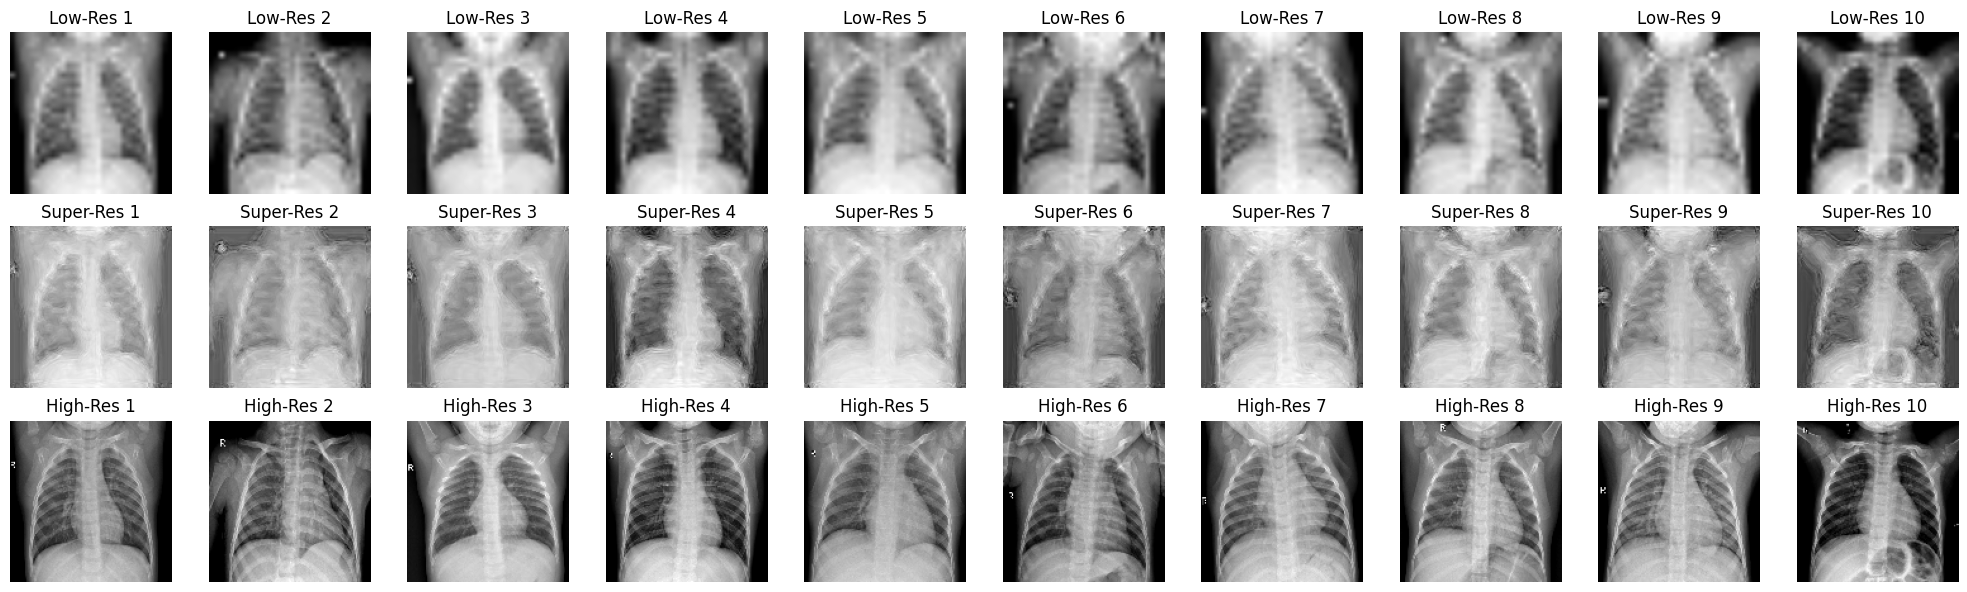

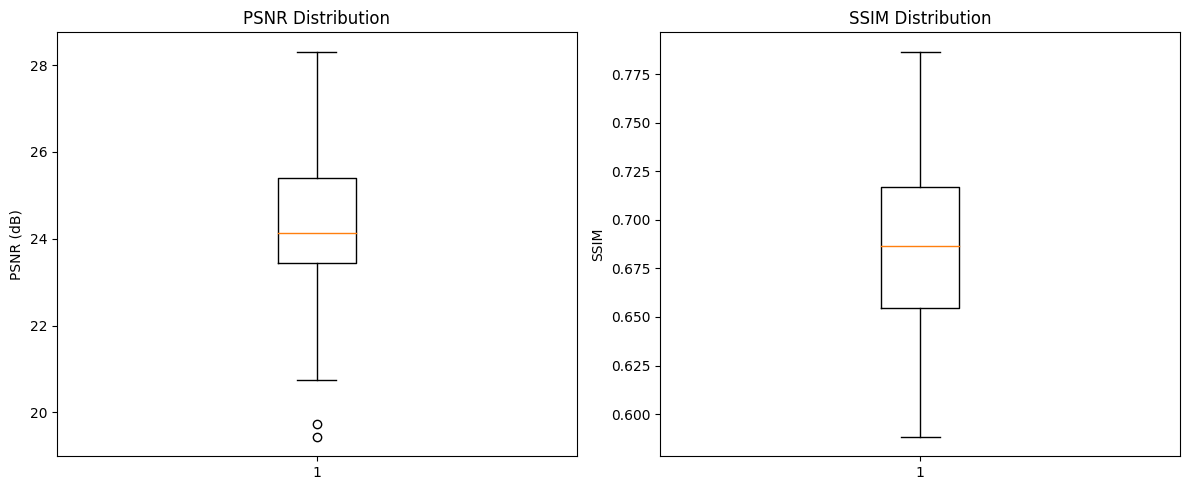

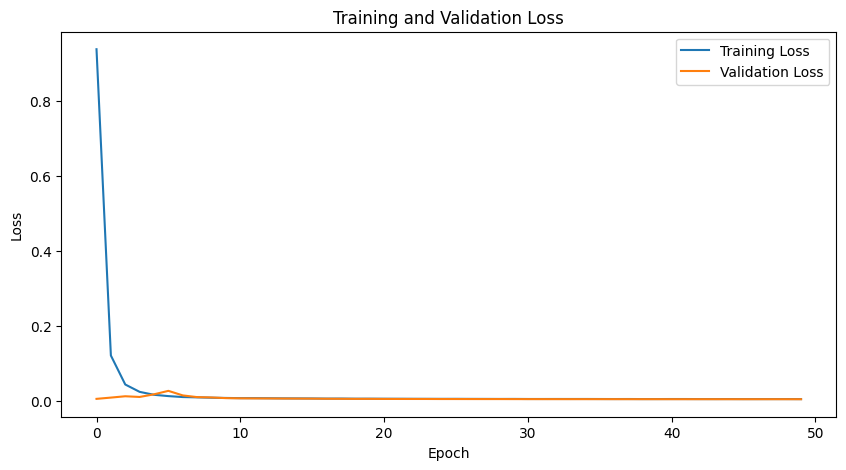

[DEBUG] Metrics saved to super_resolution_metrics.csv
Execution completed successfully!


In [8]:
if __name__ == "__main__":
    main()